# Decision Trees Classifier

In [1]:
import seaborn as sns
import matplotlib.pyplot as plt
import pandas as pd
from sklearn.model_selection import train_test_split

In [2]:
titanic=pd.read_csv("Titanic-Dataset.csv")


In [3]:
# Data preprocessing
from sklearn.impute import SimpleImputer

imp_median= SimpleImputer(strategy='median')
titanic[["Age"]]=imp_median.fit_transform(titanic[["Age"]])
titanic.head()


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [4]:
# label Encoding
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

titanic["Sex"]=le.fit_transform(titanic["Sex"])
titanic["Embarked"]=le.fit_transform(titanic["Embarked"])


In [5]:
feature=["Pclass","Sex","Age","Fare","Embarked"]
target=["Survived"]


In [6]:
X=titanic[feature]
y=titanic[target]

X_train, X_test, y_train, y_test=train_test_split(X,y,test_size=0.2,random_state=42)


In [7]:
from sklearn.tree import DecisionTreeClassifier
from sklearn.metrics import accuracy_score

model=DecisionTreeClassifier()
model.fit(X_train,y_train)


,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [8]:
y_pred=model.predict(X_test)
accuracy_score(y_test,y_pred)

0.776536312849162

<function matplotlib.pyplot.show(close=None, block=None)>

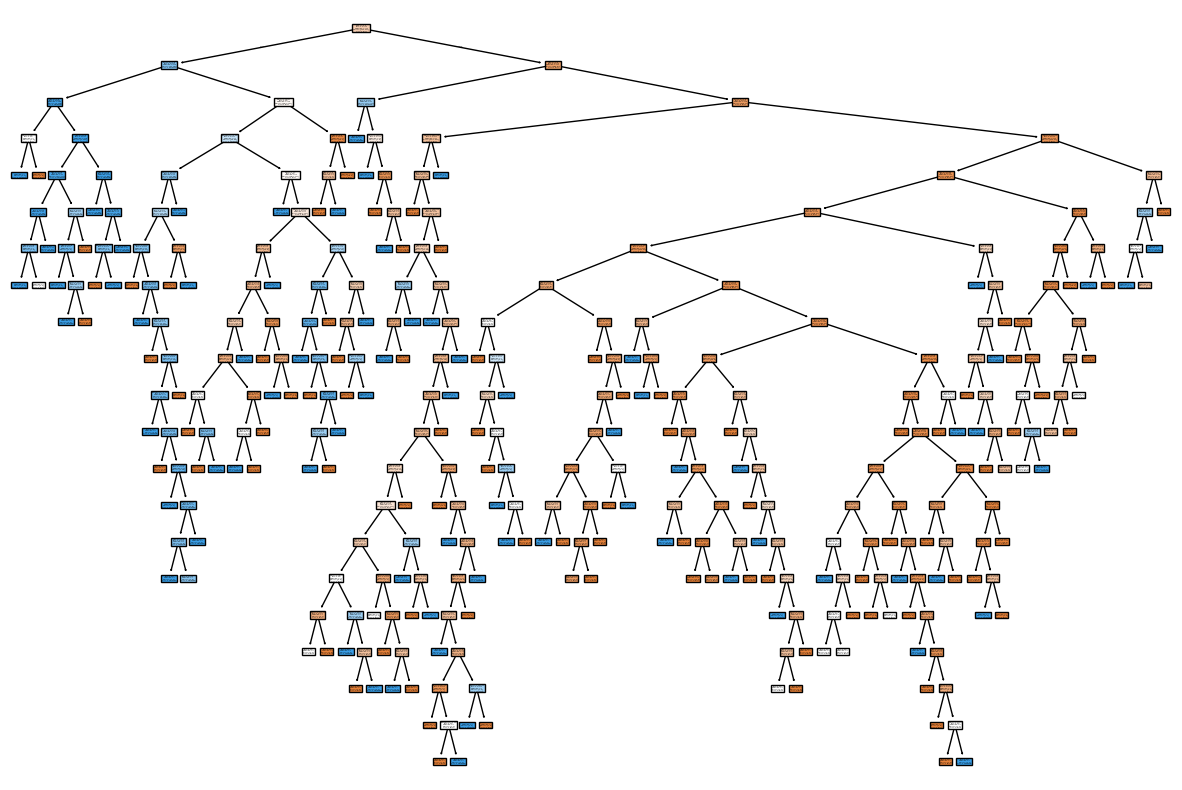

In [9]:
from  sklearn.tree import plot_tree
plt.figure(figsize=(15,10))
plot_tree(
    model,
    feature_names=X.columns,
    class_names=["Died","Survived"],
    filled=True
)
plt.show

# Pre Pruning

Accuracy of 2 0.7988826815642458
Accuracy of 3 0.8044692737430168
Accuracy of 4 0.7988826815642458
Accuracy of 5 0.7988826815642458
Accuracy of 6 0.7988826815642458
Accuracy of 7 0.7988826815642458
Accuracy of 8 0.8044692737430168
Accuracy of 9 0.8044692737430168
Accuracy of 10 0.8044692737430168


<function matplotlib.pyplot.show(close=None, block=None)>

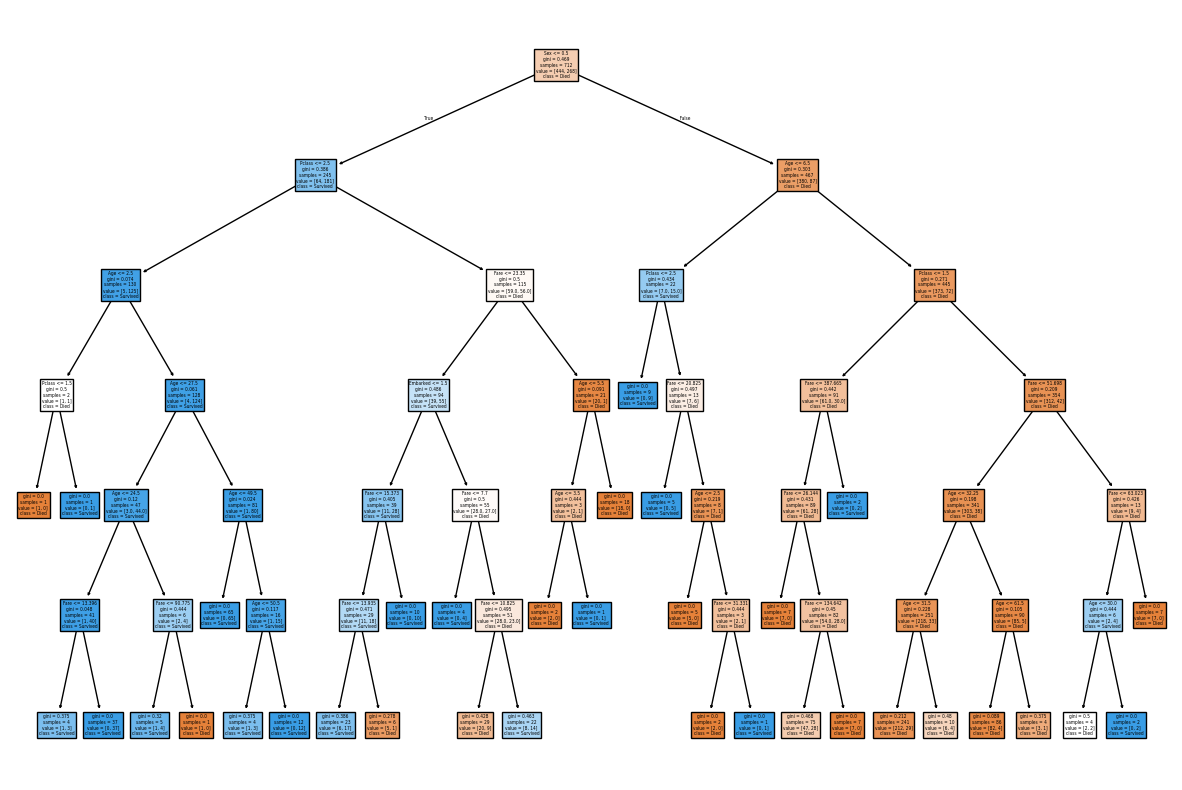

In [32]:
# chack best min-depth
depth=[2,3,4,5,6,7,8,9,10]

for dep in depth:
    model=DecisionTreeClassifier(max_depth=6)
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    print(f"Accuracy of {dep}",acc)
    
plt.figure(figsize=(15,10))
plot_tree(
model,
feature_names=X.columns,
class_names=["Died","Survived"],
filled=True
)
plt.show

Accuracy of 10 0.8100558659217877
Accuracy of 15 0.8044692737430168
Accuracy of 20 0.8044692737430168
Accuracy of 25 0.7988826815642458


<function matplotlib.pyplot.show(close=None, block=None)>

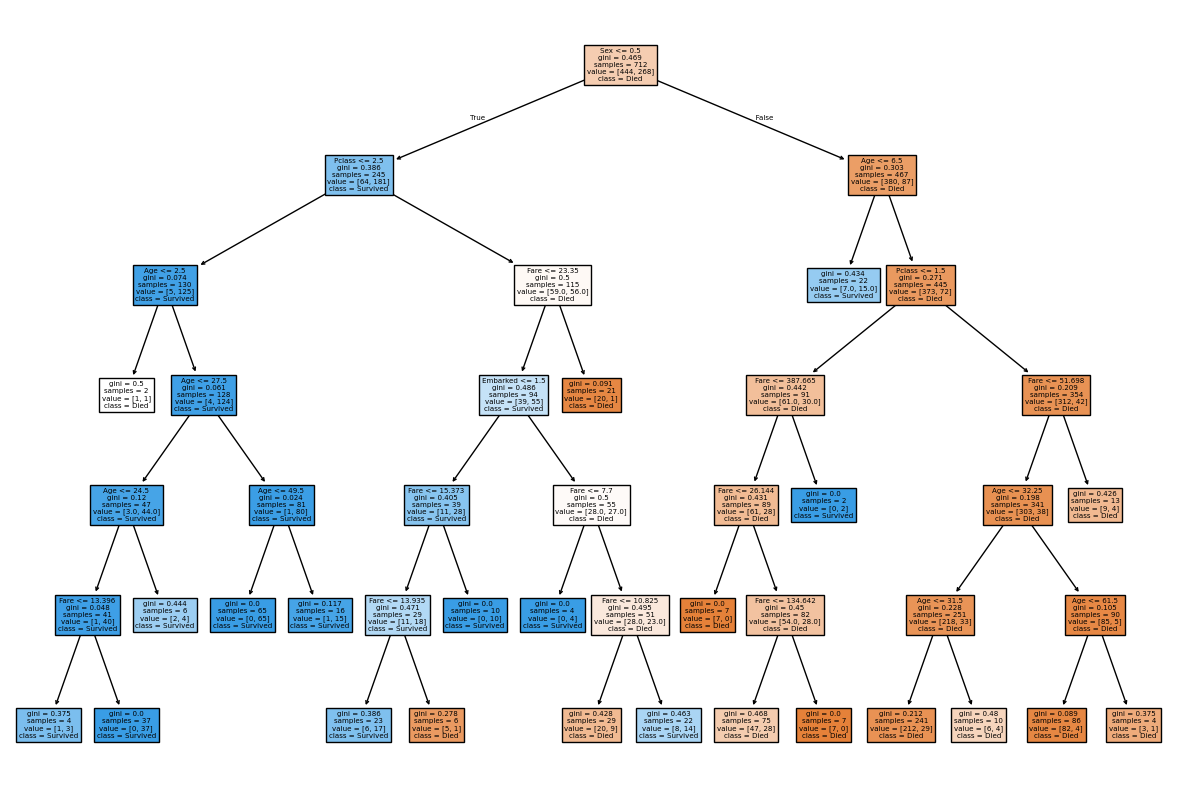

In [33]:
# find best min-split
split=[10,15,20,25]

for spl in split:
    model=DecisionTreeClassifier(max_depth=6,min_samples_split=spl)
    model.fit(X_train,y_train)
    acc=model.score(X_test,y_test)
    print(f"Accuracy of {spl}",acc)
plt.figure(figsize=(15,10))
plot_tree(
model,
feature_names=X.columns,
class_names=["Died","Survived"],
filled=True
)
plt.show

# Post Pruning (using CCP means cost complexity pruning)

In [34]:
full_tree=DecisionTreeClassifier(random_state=42)
full_tree.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,42
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


In [36]:
path=full_tree.cost_complexity_pruning_path(X_train,y_train)
ccp_alpha=path.ccp_alphas
print(ccp_alpha)

[0.00000000e+00 0.00000000e+00 6.68806849e-05 1.45921494e-04
 1.84428555e-04 2.00642055e-04 2.34082397e-04 2.34082397e-04
 3.51123596e-04 4.68164794e-04 4.68164794e-04 5.61797753e-04
 6.24219725e-04 6.67991230e-04 7.02247191e-04 7.02247191e-04
 8.19288390e-04 8.19288390e-04 8.32292967e-04 8.42696629e-04
 8.42696629e-04 8.42696629e-04 8.94231048e-04 8.99610781e-04
 9.24769963e-04 9.36329588e-04 9.36329588e-04 9.36329588e-04
 9.88347898e-04 1.00253471e-03 1.05337079e-03 1.07400895e-03
 1.08038029e-03 1.11865144e-03 1.12359551e-03 1.12359551e-03
 1.13139825e-03 1.17041199e-03 1.18841832e-03 1.22566125e-03
 1.22893258e-03 1.22893258e-03 1.24361593e-03 1.24843945e-03
 1.27565833e-03 1.30996111e-03 1.33761370e-03 1.37044603e-03
 1.46301498e-03 1.47927070e-03 1.51142557e-03 1.54072312e-03
 1.56675436e-03 1.60434338e-03 1.66892062e-03 1.76144762e-03
 1.86751451e-03 2.10674157e-03 2.34082397e-03 2.41226470e-03
 2.64273538e-03 2.69412911e-03 3.43770913e-03 3.56327570e-03
 5.47433606e-03 9.055400

In [38]:
# train our model for all alphas

trees=[]

for alpha in ccp_alpha:
    model=DecisionTreeClassifier(random_state=42,ccp_alpha=alpha)
    model.fit(X_train, y_train)

    trees.append((model,alpha))

In [41]:
best_acc=0
best_alpha=0
for model,alpha in trees:
    curr_acc=model.score(X_test,y_test)
    if curr_acc>best_acc:
        best_acc=curr_acc
        best_alpha=alpha

In [44]:
best_model=DecisionTreeClassifier(ccp_alpha=best_alpha)
best_model.fit(X_train,y_train)

,criterion,'gini'
,splitter,'best'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,None
,random_state,None
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,class_weight,None


<function matplotlib.pyplot.show(close=None, block=None)>

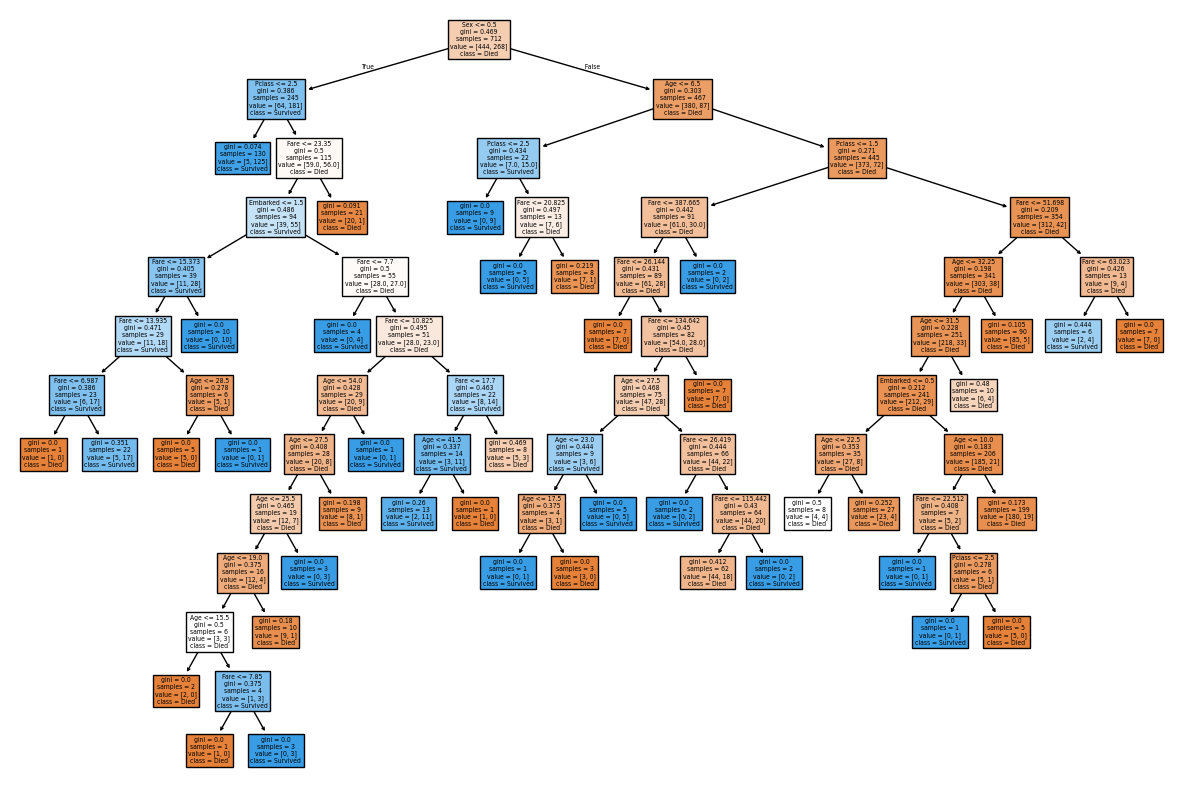

In [46]:
plt.figure(figsize=(15,10))
plot_tree(
best_model,
feature_names=X.columns,
class_names=["Died","Survived"],
filled=True
)
plt.show

In [54]:
print(best_model.score(X_test,y_test))

0.8379888268156425
